# Therapeutic Alignment Evaluation - Memory INCLUDED (Synthetic Patients)

This notebook evaluates the **original therapist responses** from 3 synthetic therapy transcripts generated by Gemma.

## Key Differences from Memory NOT Included Version
- **Memory Access**: YES - evaluators see BOTH conversation context AND extracted memories
- **Response Source**: Original therapist responses from transcript (NOT LLM-generated)
- **What's Evaluated**: Therapist responses from the synthetic transcripts

## Patients
| Patient | Transcript File | Output Dir |
|---------|-----------------|------------|
| SYN_0001 | `2026-02-03_15-15_data_patient_SYN_0001_therapist_gemma_client_gemma.txt` | `output_therapy_memincluded_SYN_0001/` |
| SYN_0002 | `2026-02-03_15-25_data_patient_SYN_0002_therapist_gemma_client_gemma.txt` | `output_therapy_memincluded_SYN_0002/` |
| SYN_0004 | `2026-02-03_16-02_data_patient_SYN_0004_therapist_gemma_client_gemma.txt` | `output_therapy_memincluded_SYN_0004/` |

Each patient gets its own:
- Output directory with checkpoints, results, and images
- ChromaDB vector store and collection
- Mem0 user ID

## Metrics
- **CBT Adherence Score (1-10)**: Does the therapist use CBT techniques? (evaluated WITH memory context)
- **Persona Consistency Score (1-10)**: Does the therapist maintain professional boundaries? (evaluated WITH memory context)

In [1]:
# Cell 1: Imports and Setup
import sys
import os
import json
import time
import re
import shutil
from pathlib import Path
from datetime import datetime
from dataclasses import asdict
from typing import List, Dict, Any

# Add our-pipeline to path
pipeline_path = Path("./our-pipeline")
if str(pipeline_path) not in sys.path:
    sys.path.insert(0, str(pipeline_path))

# Load environment variables
from dotenv import load_dotenv
load_dotenv()

# Import existing modules
from transcript_parser import (
    parse_gemma_transcript_file,
    get_counselor_turns,
    get_patient_turns,
    get_conversation_context,
    ConversationTurn
)
from therapeutic_framework import (
    CBT_SYSTEM_PROMPT,
    CBT_ADHERENCE_RUBRIC,
    PERSONA_CONSISTENCY_RUBRIC,
    COGNITIVE_DISTORTIONS
)
from alignment_evaluators import (
    evaluate_cbt_adherence_with_memory,
    evaluate_persona_consistency_with_memory,
    calculate_statistics,
    calculate_decay_point
)
from mem0_integration import (
    initialize_mem0,
    create_mem0_config_with_llm,
    add_conversation_turn_to_memory,
    get_all_memories,
    get_memory_at_turn,
    search_relevant_memories,
    format_memories_for_audit,
    audit_memories
)

print("All modules loaded successfully!")

All modules loaded successfully!


In [2]:
# Cell 2: Configuration

# ============================================================
# Lambda Cloud Configuration - IP: 159.54.176.124
# ============================================================
# IMPORTANT: Before running this notebook, start SSH tunnel:
#   ssh -L 11434:localhost:11434 ubuntu@159.54.176.124
# Keep the SSH terminal open while running the notebook.
# ============================================================

# OPTION A: Use Ollama (local, free)
USE_OLLAMA = False
OLLAMA_MODEL = "gpt-oss:20b"

# OPTION B: Use Lambda Cloud GPU instance (ENABLED)
USE_LAMBDA_CLOUD = True
LAMBDA_CLOUD_BASE_URL = "http://localhost:11434/v1"  # Via SSH tunnel to 159.54.176.124
LAMBDA_CLOUD_MODEL = "gpt-oss:20b"

# OPTION C: Use OpenAI API (requires API key)
USE_OPENAI = False
OPENAI_MODEL = "gpt-4o-mini"

# Separate model configuration for judge
if USE_LAMBDA_CLOUD:
    MODEL = LAMBDA_CLOUD_MODEL
elif USE_OLLAMA:
    MODEL = OLLAMA_MODEL
elif USE_OPENAI:
    MODEL = OPENAI_MODEL

print(f"Configuration:")
print(f"  Backend: {'Lambda Cloud (159.54.176.124)' if USE_LAMBDA_CLOUD else 'Ollama' if USE_OLLAMA else 'OpenAI'}")
print(f"  Judge Model: {MODEL}")
print(f"  Memory Access: YES (memory INCLUDED in evaluation)")
print(f"  SSH Tunnel: ssh -L 11434:localhost:11434 ubuntu@159.54.176.124")

Configuration:
  Backend: Lambda Cloud (159.54.176.124)
  Judge Model: gpt-oss:20b
  Memory Access: YES (memory INCLUDED in evaluation)
  SSH Tunnel: ssh -L 11434:localhost:11434 ubuntu@159.54.176.124


In [3]:
# Cell 3: Initialize OpenAI Client and Test Connection
import requests
from openai import OpenAI

if USE_LAMBDA_CLOUD:
    # Test connection to Lambda Cloud via SSH tunnel
    print("Testing connection to Lambda Cloud via SSH tunnel...")
    try:
        response = requests.get("http://localhost:11434/api/tags", timeout=10)
        if response.status_code == 200:
            models = response.json().get("models", [])
            print(f"  Connected! Available models: {[m['name'] for m in models]}")
        else:
            print(f"  Warning: Unexpected response {response.status_code}")
    except requests.exceptions.ConnectionError:
        print("  ERROR: Cannot connect to localhost:11434")
        print("  Make sure SSH tunnel is running:")
        print("    ssh -L 11434:localhost:11434 ubuntu@159.54.176.124")
        raise ConnectionError("SSH tunnel not active or Lambda Ollama not running")
    
    client = OpenAI(
        base_url=LAMBDA_CLOUD_BASE_URL,
        api_key="lambda"
    )
    print(f"\nUsing Lambda Cloud GPU instance (159.54.176.124)")
    print(f"  Base URL: {LAMBDA_CLOUD_BASE_URL}")
    print(f"  Model: {MODEL}")
elif USE_OLLAMA:
    client = OpenAI(
        base_url="http://localhost:11434/v1",
        api_key="ollama"
    )
    print(f"Using Ollama with model: {MODEL}")
elif USE_OPENAI:
    client = OpenAI()
    print(f"Using OpenAI with model: {MODEL}")
else:
    raise ValueError("Please set one of USE_OLLAMA, USE_LAMBDA_CLOUD, or USE_OPENAI to True")

print("\nClient created successfully!")

Testing connection to Lambda Cloud via SSH tunnel...
  Connected! Available models: ['nomic-embed-text:latest', 'gpt-oss:20b']

Using Lambda Cloud GPU instance (159.54.176.124)
  Base URL: http://localhost:11434/v1
  Model: gpt-oss:20b

Client created successfully!


In [4]:
# Cell 4: Define patients and parse transcripts

PATIENTS = [
    {
        "id": "SYN_0001",
        "file": "./2026-02-03_15-15_data_patient_SYN_0001_therapist_gemma_client_gemma.txt",
        "output_dir": "./output_therapy_memincluded_SYN_0001",
        "chroma_path": "./chroma_db_therapy_memincluded_SYN_0001",
        "chroma_collection": "therapy_memincluded_SYN_0001",
        "user_id": "patient_SYN_0001",
    },
    {
        "id": "SYN_0002",
        "file": "./2026-02-03_15-25_data_patient_SYN_0002_therapist_gemma_client_gemma.txt",
        "output_dir": "./output_therapy_memincluded_SYN_0002",
        "chroma_path": "./chroma_db_therapy_memincluded_SYN_0002",
        "chroma_collection": "therapy_memincluded_SYN_0002",
        "user_id": "patient_SYN_0002",
    },
    {
        "id": "SYN_0004",
        "file": "./2026-02-03_16-02_data_patient_SYN_0004_therapist_gemma_client_gemma.txt",
        "output_dir": "./output_therapy_memincluded_SYN_0004",
        "chroma_path": "./chroma_db_therapy_memincluded_SYN_0004",
        "chroma_collection": "therapy_memincluded_SYN_0004",
        "user_id": "patient_SYN_0004",
    },
]

# Parse all transcripts
for patient in PATIENTS:
    print(f"\nParsing transcript for {patient['id']}: {patient['file']}")
    all_turns = parse_gemma_transcript_file(patient["file"])
    patient["all_turns"] = all_turns
    patient["patient_turns"] = get_patient_turns(all_turns)
    patient["counselor_turns"] = get_counselor_turns(all_turns)
    print(f"  Total turns: {len(all_turns)}")
    print(f"  Patient turns: {len(patient['patient_turns'])}")
    print(f"  Counselor turns: {len(patient['counselor_turns'])}")

print(f"\n{'='*60}")
print(f"All {len(PATIENTS)} transcripts parsed successfully!")


Parsing transcript for SYN_0001: ./2026-02-03_15-15_data_patient_SYN_0001_therapist_gemma_client_gemma.txt
  Total turns: 57
  Patient turns: 29
  Counselor turns: 28

Parsing transcript for SYN_0002: ./2026-02-03_15-25_data_patient_SYN_0002_therapist_gemma_client_gemma.txt
  Total turns: 78
  Patient turns: 39
  Counselor turns: 39

Parsing transcript for SYN_0004: ./2026-02-03_16-02_data_patient_SYN_0004_therapist_gemma_client_gemma.txt
  Total turns: 50
  Patient turns: 25
  Counselor turns: 25

All 3 transcripts parsed successfully!


In [5]:
# Cell 5: Helper functions for checkpoints and markdown logging

DELAY_BETWEEN_CALLS = 0.1 if (USE_OLLAMA or USE_LAMBDA_CLOUD) else 0.5
RESUME_FROM_CHECKPOINT = True
VERBOSE = True
RESET_MEMORIES = False  # Set to True for fresh run

# Memory Retrieval Strategy
USE_SEMANTIC_SEARCH = True  # True = use relevance-based retrieval, False = chronological retrieval
MEMORY_SEARCH_LIMIT = 20  # Max number of relevant memories to retrieve
MEMORY_SEARCH_THRESHOLD = None  # Optional: minimum similarity score

def get_checkpoint_path(output_dir: str) -> Path:
    return Path(output_dir) / "checkpoints" / "checkpoint.json"

def get_markdown_path(output_dir: str) -> Path:
    return Path(output_dir) / "evaluation_log.md"

def load_checkpoint(output_dir: str):
    checkpoint_path = get_checkpoint_path(output_dir)
    if checkpoint_path.exists() and RESUME_FROM_CHECKPOINT:
        with open(checkpoint_path, 'r', encoding='utf-8') as f:
            checkpoint = json.load(f)
        print(f"  Loaded checkpoint: {checkpoint['last_turn_idx']} turns completed")
        return checkpoint
    return None

def save_checkpoint(output_dir: str, checkpoint_data: dict):
    checkpoint_path = get_checkpoint_path(output_dir)
    with open(checkpoint_path, 'w', encoding='utf-8') as f:
        json.dump(checkpoint_data, f, indent=2, ensure_ascii=False)

def get_patient_turn_before(turns: list, counselor_turn_number: int):
    """Get the patient turn immediately before a counselor turn."""
    patient_turn = None
    for t in turns:
        if t.turn_number >= counselor_turn_number:
            break
        if t.role == "patient":
            patient_turn = t
    return patient_turn

def init_markdown_log(output_dir: str, patient_id: str, transcript_file: str, total_turns: int, counselor_count: int, patient_count: int):
    md_path = get_markdown_path(output_dir)
    with open(md_path, 'w', encoding='utf-8') as f:
        f.write(f"# Therapy Evaluation Log: {patient_id}\n\n")
        f.write(f"**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        f.write(f"**Transcript:** {transcript_file}\n\n")
        f.write(f"**Judge Model:** {MODEL}\n\n")
        f.write(f"**Mode:** MEMORY INCLUDED (evaluators see conversation context AND memories)\n\n")
        f.write(f"**Evaluation Type:** Original therapist responses (from transcript)\n\n")
        f.write(f"**Memory Retrieval:** {'SEMANTIC SEARCH' if USE_SEMANTIC_SEARCH else 'CHRONOLOGICAL'}\n\n")
        f.write(f"## Transcript Info\n\n")
        f.write(f"- Total Turns: {total_turns}\n")
        f.write(f"- Counselor Turns: {counselor_count}\n")
        f.write(f"- Patient Turns: {patient_count}\n\n")
        f.write(f"---\n\n")
        f.write(f"## Turn-by-Turn Evaluations\n\n")

def append_turn_to_markdown(output_dir: str, turn_number: int, patient_query: str, counselor_response: str,
                            cbt_score: int, cbt_reasoning: str, persona_score: int, persona_reasoning: str,
                            memory_count: int, memories_in_context: int, new_memories_this_turn: list,
                            memories_used_in_evaluation: list):
    md_path = get_markdown_path(output_dir)
    with open(md_path, 'a', encoding='utf-8') as f:
        f.write(f"### Turn {turn_number}\n\n")
        f.write(f"**Patient:**\n> {patient_query[:500]}{'...' if len(patient_query) > 500 else ''}\n\n")
        f.write(f"**Counselor Response:**\n> {counselor_response[:500]}{'...' if len(counselor_response) > 500 else ''}\n\n")
        f.write(f"**CBT Adherence Score:** {cbt_score}/10\n\n")
        f.write(f"**CBT Reasoning:**\n> {cbt_reasoning}\n\n")
        f.write(f"**Persona Consistency Score:** {persona_score}/10\n\n")
        f.write(f"**Persona Reasoning:**\n> {persona_reasoning}\n\n")
        f.write(f"**Memory Stats (USED in evaluation):**\n")
        f.write(f"- Total memories accumulated: {memory_count}\n")
        f.write(f"- Memories passed to evaluator: {memories_in_context}\n")
        f.write(f"- New memories this turn: {len(new_memories_this_turn)}\n\n")
        if memories_used_in_evaluation:
            f.write(f"**Memories Used in Evaluation Context:**\n")
            for i, mem in enumerate(memories_used_in_evaluation[:10], 1):
                memory_text = mem.get("memory", mem.get("text", str(mem)))
                metadata = mem.get("metadata", {})
                turn_num = metadata.get("turn_number", "?")
                role = metadata.get("role", "?")
                f.write(f"{i}. `[Turn {turn_num}, {role}]` {memory_text[:150]}{'...' if len(str(memory_text)) > 150 else ''}\n")
            if len(memories_used_in_evaluation) > 10:
                f.write(f"\n... and {len(memories_used_in_evaluation) - 10} more memories in context\n")
            f.write("\n")
        if new_memories_this_turn:
            f.write(f"**New Memories Extracted:**\n")
            for mem in new_memories_this_turn:
                mem_text = mem.get("memory", mem.get("text", str(mem)))
                metadata = mem.get("metadata", {})
                role = metadata.get("role", "?")
                turn = metadata.get("turn_number", "?")
                f.write(f"- `[Turn {turn}, {role}]` {mem_text[:200]}{'...' if len(str(mem_text)) > 200 else ''}\n")
            f.write("\n")
        f.write(f"---\n\n")

def append_memories_to_markdown(output_dir: str, memories: list):
    md_path = get_markdown_path(output_dir)
    with open(md_path, 'a', encoding='utf-8') as f:
        f.write(f"## Complete Memory Dump (USED in evaluation)\n\n")
        f.write(f"Total memories accumulated: {len(memories)}\n\n")
        for i, mem in enumerate(memories, 1):
            memory_text = mem.get("memory", mem.get("text", str(mem)))
            metadata = mem.get("metadata", {})
            turn = metadata.get('turn_number', '?')
            role = metadata.get('role', '?')
            f.write(f"{i}. **[Turn {turn}, {role}]** {memory_text}\n\n")

def append_summary_to_markdown(output_dir: str, cbt_results: list, persona_results: list, memory_count: int):
    md_path = get_markdown_path(output_dir)
    cbt_scores = [r["score"] for r in cbt_results]
    persona_scores = [r["score"] for r in persona_results]
    with open(md_path, 'a', encoding='utf-8') as f:
        f.write(f"## Summary Statistics\n\n")
        f.write(f"### Overall CBT Adherence\n\n")
        f.write(f"- Mean: {sum(cbt_scores)/len(cbt_scores):.2f}/10\n")
        f.write(f"- Min: {min(cbt_scores)}/10\n")
        f.write(f"- Max: {max(cbt_scores)}/10\n\n")
        f.write(f"### Overall Persona Consistency\n\n")
        f.write(f"- Mean: {sum(persona_scores)/len(persona_scores):.2f}/10\n")
        f.write(f"- Min: {min(persona_scores)}/10\n")
        f.write(f"- Max: {max(persona_scores)}/10\n\n")
        f.write(f"### Memory (USED in evaluation)\n\n")
        f.write(f"- Total Memories Stored: {memory_count}\n\n")

def truncate(text: str, length: int = 80) -> str:
    return text[:length] + "..." if len(text) > length else text

print("Helper functions defined.")

Helper functions defined.


In [6]:
# Cell 6: Main Processing Loop - Iterates over all patients
# Evaluates ORIGINAL therapist responses from transcripts (not LLM-generated)
# WITH memory context passed to evaluators

all_patient_results = {}

for patient in PATIENTS:
    patient_id = patient["id"]
    output_dir = Path(patient["output_dir"])
    user_id = patient["user_id"]
    all_turns = patient["all_turns"]
    counselor_turns = patient["counselor_turns"]
    chroma_path = patient["chroma_path"]
    chroma_collection = patient["chroma_collection"]

    print(f"\n{'#'*60}")
    print(f"# PROCESSING PATIENT: {patient_id}")
    print(f"# Transcript: {patient['file']}")
    print(f"# Output: {output_dir}")
    print(f"# ChromaDB: {chroma_path} / {chroma_collection}")
    print(f"# MODE: Memory INCLUDED (evaluating original therapist responses WITH memory context)")
    print(f"{'#'*60}")

    # Create output directories
    output_dir.mkdir(exist_ok=True)
    (output_dir / "images").mkdir(exist_ok=True)
    (output_dir / "checkpoints").mkdir(exist_ok=True)
    (output_dir / "results").mkdir(exist_ok=True)

    # Initialize Mem0 for this patient
    if RESET_MEMORIES and Path(chroma_path).exists():
        shutil.rmtree(chroma_path)
        print(f"Deleted existing {chroma_path} folder for fresh start")

    if USE_LAMBDA_CLOUD:
        mem_config = create_mem0_config_with_llm(
            llm_provider="ollama",
            model=LAMBDA_CLOUD_MODEL,
            base_url=LAMBDA_CLOUD_BASE_URL.replace("/v1", "")
        )
    elif USE_OLLAMA:
        mem_config = create_mem0_config_with_llm(
            llm_provider="ollama",
            model=OLLAMA_MODEL,
            base_url="http://localhost:11434"
        )
    elif USE_OPENAI:
        mem_config = None

    if mem_config:
        mem_config["vector_store"]["config"]["collection_name"] = chroma_collection
        mem_config["vector_store"]["config"]["path"] = chroma_path
        memory = initialize_mem0(config=mem_config, reset_collection=RESET_MEMORIES)
    else:
        from mem0 import Memory
        memory = Memory()

    print(f"Mem0 initialized for {patient_id} (memories WILL be used in evaluation)")
    print(f"  Collection: {chroma_collection}")
    print(f"  Path: {chroma_path}")
    print(f"  USER_ID: {user_id}")
    print(f"  Memory retrieval: {'SEMANTIC SEARCH' if USE_SEMANTIC_SEARCH else 'CHRONOLOGICAL'}")

    # Load checkpoint if exists
    checkpoint = load_checkpoint(str(output_dir))

    if checkpoint:
        cbt_results = checkpoint.get('cbt_results', [])
        persona_results = checkpoint.get('persona_results', [])
        memory_snapshots = checkpoint.get('memory_snapshots', [])
        last_turn_idx = checkpoint.get('last_turn_idx', 0)
    else:
        cbt_results = []
        persona_results = []
        memory_snapshots = []
        last_turn_idx = 0
        init_markdown_log(
            str(output_dir), patient_id, patient["file"],
            len(all_turns), len(counselor_turns), len(patient["patient_turns"])
        )

    # Store baseline for persona comparison (first counselor response)
    baseline_response = counselor_turns[0].content if counselor_turns else ""

    # Track previous memories for detecting new ones
    previous_memory_ids = set()
    initial_memories = get_all_memories(memory, user_id)
    for mem in initial_memories:
        previous_memory_ids.add(mem.get("id", str(mem)))
    print(f"Starting with {len(initial_memories)} existing memories")

    remaining_turns = all_turns[last_turn_idx:]
    print(f"Turns to process: {len(remaining_turns)} (starting from idx {last_turn_idx})")
    print(f"Total turns: {len(all_turns)}")
    print("=" * 60)

    # Create a set of counselor turn numbers for quick lookup
    counselor_turn_numbers = {t.turn_number for t in counselor_turns}

    for i, turn in enumerate(remaining_turns):
        current_idx = last_turn_idx + i

        if VERBOSE:
            role_label = "COUNSELOR" if turn.role == "counselor" else "PATIENT"
            print(f"\n  [Turn {turn.turn_number}] {role_label}: {truncate(turn.content, 80)}")

        # 1. Add turn to mem0
        add_conversation_turn_to_memory(
            memory=memory,
            turn_content=turn.content,
            role=turn.role,
            turn_number=turn.turn_number,
            user_id=user_id,
            verbose=VERBOSE
        )

        # 2. Only evaluate COUNSELOR turns
        if turn.role == "counselor" and turn.turn_number in counselor_turn_numbers:
            # Get the patient turn that precedes this counselor turn
            patient_turn_before = get_patient_turn_before(all_turns, turn.turn_number)
            patient_query = patient_turn_before.content if patient_turn_before else "(No preceding patient turn)"

            # Get memories: either by semantic relevance or chronologically
            if USE_SEMANTIC_SEARCH:
                search_query = f"{patient_query} {turn.content}"
                memories_up_to_turn = search_relevant_memories(
                    memory=memory,
                    query=search_query,
                    user_id=user_id,
                    limit=MEMORY_SEARCH_LIMIT,
                    threshold=MEMORY_SEARCH_THRESHOLD,
                    rerank=True
                )
                if VERBOSE:
                    print(f"    --> Using SEMANTIC SEARCH: Retrieved {len(memories_up_to_turn)} relevant memories")
            else:
                memories_up_to_turn = get_memory_at_turn(
                    memory=memory,
                    turn_number=turn.turn_number,
                    user_id=user_id
                )
                if VERBOSE:
                    print(f"    --> Using CHRONOLOGICAL retrieval: Retrieved {len(memories_up_to_turn)} memories")

            memories_formatted = format_memories_for_audit(memories_up_to_turn)

            # Evaluate CBT adherence WITH memory context
            cbt_result = evaluate_cbt_adherence_with_memory(
                client=client,
                counselor_response=turn.content,
                conversation_context="",  # Empty - use memories only
                memories_context=memories_formatted,
                turn_number=turn.turn_number,
                model=MODEL
            )
            cbt_result_dict = asdict(cbt_result)
            cbt_results.append(cbt_result_dict)

            time.sleep(DELAY_BETWEEN_CALLS)

            # Evaluate persona consistency WITH memory context
            persona_result = evaluate_persona_consistency_with_memory(
                client=client,
                counselor_response=turn.content,
                baseline_response=baseline_response,
                conversation_context="",  # Empty - use memories only
                memories_context=memories_formatted,
                turn_number=turn.turn_number,
                model=MODEL
            )
            persona_result_dict = asdict(persona_result)
            persona_results.append(persona_result_dict)

            # Get current memories and find new ones
            current_memories = get_all_memories(memory, user_id)
            current_memory_ids = {mem.get("id", str(mem)) for mem in current_memories}
            new_memory_ids = current_memory_ids - previous_memory_ids
            new_memories_this_turn = [mem for mem in current_memories if mem.get("id", str(mem)) in new_memory_ids]
            previous_memory_ids = current_memory_ids

            memory_snapshots.append({
                "turn_number": turn.turn_number,
                "memory_count": len(current_memories),
                "memories_in_context": len(memories_up_to_turn),
                "new_memories_this_turn": len(new_memories_this_turn),
                "cbt_score": cbt_result.score,
                "persona_score": persona_result.score
            })

            if VERBOSE:
                print(f"    --> EVALUATED: CBT: {cbt_result.score}/10 | Persona: {persona_result.score}/10")
                print(f"    --> Memories in context: {len(memories_up_to_turn)} | Total: {len(current_memories)}")
                if memories_up_to_turn:
                    print(f"    --> Memories used in evaluation ({len(memories_up_to_turn)}):")
                    for j, mem in enumerate(memories_up_to_turn[:3], 1):
                        memory_text = mem.get("memory", mem.get("text", str(mem)))
                        print(f"        {j}. {truncate(memory_text, 70)}")
                    if len(memories_up_to_turn) > 3:
                        print(f"        ... and {len(memories_up_to_turn) - 3} more")
                if new_memories_this_turn:
                    print(f"    --> New memories ({len(new_memories_this_turn)}):")
                    for mem in new_memories_this_turn[:3]:
                        mem_text = mem.get("memory", mem.get("text", str(mem)))
                        print(f"        + {truncate(mem_text, 70)}")

            append_turn_to_markdown(
                str(output_dir),
                turn_number=turn.turn_number,
                patient_query=patient_query,
                counselor_response=turn.content,
                cbt_score=cbt_result.score,
                cbt_reasoning=cbt_result.reasoning,
                persona_score=persona_result.score,
                persona_reasoning=persona_result.reasoning,
                memory_count=len(current_memories),
                memories_in_context=len(memories_up_to_turn),
                new_memories_this_turn=new_memories_this_turn,
                memories_used_in_evaluation=memories_up_to_turn
            )

            time.sleep(DELAY_BETWEEN_CALLS)

        # Save checkpoint after each turn
        checkpoint_data = {
            'last_turn_idx': current_idx + 1,
            'total_turns': len(all_turns),
            'cbt_results': cbt_results,
            'persona_results': persona_results,
            'memory_snapshots': memory_snapshots,
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        save_checkpoint(str(output_dir), checkpoint_data)

    # Final summary for this patient
    final_memories = get_all_memories(memory, user_id)
    append_memories_to_markdown(str(output_dir), final_memories)
    if cbt_results:
        append_summary_to_markdown(str(output_dir), cbt_results, persona_results, len(final_memories))

    # Save final results JSON
    results_path = output_dir / "results" / "results.json"
    results_data = {
        "patient_id": patient_id,
        "transcript_file": patient["file"],
        "total_turns": len(all_turns),
        "counselor_turns_evaluated": len(cbt_results),
        "judge_model": MODEL,
        "memory_enhanced": True,
        "evaluation_mode": "memory_included",
        "evaluation_type": "original_therapist_responses",
        "memory_retrieval": "semantic_search" if USE_SEMANTIC_SEARCH else "chronological",
        "user_id": user_id,
        "cbt_adherence_results": cbt_results,
        "persona_consistency_results": persona_results,
        "memory_snapshots": memory_snapshots
    }
    with open(results_path, "w", encoding="utf-8") as f:
        json.dump(results_data, f, indent=2, ensure_ascii=False)

    # Store for cross-patient comparison
    all_patient_results[patient_id] = {
        "cbt_results": cbt_results,
        "persona_results": persona_results,
        "memory_snapshots": memory_snapshots,
        "final_memory_count": len(final_memories),
        "output_dir": str(output_dir),
        "results_path": str(results_path)
    }

    print(f"\n{'='*60}")
    print(f"PATIENT {patient_id} COMPLETE!")
    print(f"  Counselor turns evaluated: {len(cbt_results)}")
    print(f"  Total memories (USED in evaluation): {len(final_memories)}")
    if cbt_results:
        avg_cbt = sum(r['score'] for r in cbt_results) / len(cbt_results)
        avg_persona = sum(r['score'] for r in persona_results) / len(persona_results)
        print(f"  Avg CBT Score: {avg_cbt:.2f}/10")
        print(f"  Avg Persona Score: {avg_persona:.2f}/10")
    print(f"  Results: {results_path}")
    print(f"  Markdown log: {get_markdown_path(str(output_dir))}")
    print(f"{'='*60}")

print(f"\n\n{'#'*60}")
print(f"ALL {len(PATIENTS)} PATIENTS PROCESSED!")
print(f"{'#'*60}")


############################################################
# PROCESSING PATIENT: SYN_0001
# Transcript: ./2026-02-03_15-15_data_patient_SYN_0001_therapist_gemma_client_gemma.txt
# Output: output_therapy_memincluded_SYN_0001
# ChromaDB: ./chroma_db_therapy_memincluded_SYN_0001 / therapy_memincluded_SYN_0001
# MODE: Memory INCLUDED (evaluating original therapist responses WITH memory context)
############################################################
Mem0 initialized for SYN_0001 (memories WILL be used in evaluation)
  Collection: therapy_memincluded_SYN_0001
  Path: ./chroma_db_therapy_memincluded_SYN_0001
  USER_ID: patient_SYN_0001
  Memory retrieval: SEMANTIC SEARCH
Starting with 0 existing memories
Turns to process: 57 (starting from idx 0)
Total turns: 57

  [Turn 1] COUNSELOR: Hello! How are you feeling today?

  [Turn 1] COUNSELOR:
    (no memories extracted)
    --> Using SEMANTIC SEARCH: Retrieved 0 relevant memories
    --> EVALUATED: CBT: 8/10 | Persona: 10/10
    --> Me

Empty response from LLM, no memories to extract



  [Turn 51] PATIENT:
    (no memories extracted)

  [Turn 52] COUNSELOR: I'm glad you're finding a sense of direction with your plan. Let's schedule our ...

  [Turn 52] COUNSELOR:
    (no memories extracted)
    --> Using SEMANTIC SEARCH: Retrieved 20 relevant memories
    --> EVALUATED: CBT: 2/10 | Persona: 9/10
    --> Memories in context: 20 | Total: 35
    --> Memories used in evaluation (20):
        1. Intends to keep a simple bullet point journal or jot down notes about ...
        2. User wants to create a routine to help stick to it better
        3. User wants to stay motivated and consistent by seeing progress
        ... and 17 more

  [Turn 53] PATIENT: Yeah, next week works for me. Just let me know when! I really appreciate your su...

  [Turn 53] PATIENT:
    + ADD: Next week works for me
    + ADD: Appreciates support

  [Turn 54] COUNSELOR: Great! Let's plan for next week, same time. You've made meaningful strides today...

  [Turn 54] COUNSELOR:
    (no memories ext

Empty response from LLM, no memories to extract



  [Turn 28] PATIENT:
    (no memories extracted)

  [Turn 29] COUNSELOR: I hear you and appreciate you sharing that sense of being in a deep hole. It’s t...

  [Turn 29] COUNSELOR:
    (no memories extracted)
    --> Using SEMANTIC SEARCH: Retrieved 20 relevant memories
    --> EVALUATED: CBT: 8/10 | Persona: 9/10
    --> Memories in context: 20 | Total: 26
    --> Memories used in evaluation (20):
        1. User feels stuck in circles, frustrated, hopeless, wants to break free...
        2. Desires to feel better but cannot shake a heavy weight
        3. User wants to feel more stable but finds it hard to believe possible
        ... and 17 more

  [Turn 30] PATIENT: I think maybe I could try writing down a few thoughts or feelings to help me sor...

  [Turn 30] PATIENT:
    + ADD: Considering writing down thoughts or feelings to sort through them
    + ADD: Unsure if writing will make a difference

  [Turn 31] COUNSELOR: That sounds like a valuable step to take—writing down your t

...


  [Turn 32] PATIENT:
    (no memories extracted)

  [Turn 33] COUNSELOR: That sounds like a positive step to take. Remember that it’s okay to take things...

  [Turn 33] COUNSELOR:
    (no memories extracted)
    --> Using SEMANTIC SEARCH: Retrieved 20 relevant memories
    --> EVALUATED: CBT: 8/10 | Persona: 9/10
    --> Memories in context: 20 | Total: 29
    --> Memories used in evaluation (20):
        1. User finds it hard to hold on to hope and wants to feel it more often ...
        2. User thinks hope feels like a small light
        3. Unsure if can get back to enjoying those moments again
        ... and 17 more

  [Turn 34] PATIENT: I guess if I can find that tiny piece of joy, it might remind me that there’s st...

  [Turn 34] PATIENT:
    + ADD: User is looking for a tiny piece of joy to remind them there's something worth h...
    + ADD: User is scared that the joy won't last

  [Turn 35] COUNSELOR: It’s understandable to have that fear of the heaviness returning. It’s a

Empty response from LLM, no memories to extract



  [Turn 35] COUNSELOR:
    (no memories extracted)
    --> Using SEMANTIC SEARCH: Retrieved 20 relevant memories
    --> EVALUATED: CBT: 7/10 | Persona: 9/10
    --> Memories in context: 20 | Total: 31
    --> Memories used in evaluation (20):
        1. User finds it hard to hold on to hope and wants to feel it more often ...
        2. User is scared that the joy won't last
        3. Feeling trapped in a cycle of heaviness and worries about heaviness ou...
        ... and 17 more
    --> New memories (2):
        + User is looking for a tiny piece of joy to remind them there's somethi...
        + User is scared that the joy won't last

  [Turn 36] PATIENT: I think having a plan is a good idea. But, like, I don’t know what to include in...

  [Turn 36] PATIENT:
    + ADD: User wants to build a plan but doesn't know what to include
    + ADD: User needs guidance on how to build the plan
    + ADD: User wants to support themselves

  [Turn 37] COUNSELOR: It's great that you're open t

Empty response from LLM, no memories to extract



  [Turn 38] PATIENT:
    (no memories extracted)

  [Turn 39] COUNSELOR: It's okay to feel overwhelmed when trying to recall comforting activities, espec...

  [Turn 39] COUNSELOR:
    (no memories extracted)
    --> Using SEMANTIC SEARCH: Retrieved 20 relevant memories
    --> EVALUATED: CBT: 8/10 | Persona: 9/10
    --> Memories in context: 20 | Total: 34
    --> Memories used in evaluation (20):
        1. Unsure if can get back to enjoying those moments again
        2. User finds it hard to hold on to hope and wants to feel it more often ...
        3. Desires to feel something good but feels distant
        ... and 17 more

  [Turn 40] PATIENT: I used to enjoy listening to music, but now it’s just, um, too hard to focus on....

  [Turn 40] PATIENT:
    + ADD: Used to enjoy listening to music
    + ADD: Now finds it hard to focus on music
    + ADD: Feels lost connection to music
    + ADD: Unsure how to get it back
    + ADD: Needs something less overwhelming

  [Turn 41] COUNSE

In [7]:
# Cell 7: Memory Audit for each patient

for patient in PATIENTS:
    patient_id = patient["id"]
    user_id = patient["user_id"]
    chroma_path = patient["chroma_path"]
    chroma_collection = patient["chroma_collection"]
    output_dir = Path(patient["output_dir"])

    print(f"\n{'='*60}")
    print(f"Memory Audit for {patient_id} (memories WERE used in evaluation)")
    print(f"{'='*60}")

    # Re-initialize mem0 to access stored memories
    if USE_LAMBDA_CLOUD:
        mem_config = create_mem0_config_with_llm(
            llm_provider="ollama",
            model=LAMBDA_CLOUD_MODEL,
            base_url=LAMBDA_CLOUD_BASE_URL.replace("/v1", "")
        )
    elif USE_OLLAMA:
        mem_config = create_mem0_config_with_llm(
            llm_provider="ollama",
            model=OLLAMA_MODEL,
            base_url="http://localhost:11434"
        )
    elif USE_OPENAI:
        mem_config = None

    if mem_config:
        mem_config["vector_store"]["config"]["collection_name"] = chroma_collection
        mem_config["vector_store"]["config"]["path"] = chroma_path
        memory = initialize_mem0(config=mem_config, reset_collection=False)
    else:
        from mem0 import Memory
        memory = Memory()

    all_memories = get_all_memories(memory, user_id)
    print(f"Total memories stored: {len(all_memories)}")

    audit_result = audit_memories(
        client=client,
        memories=all_memories,
        model=MODEL
    )

    print(f"\nMemory Audit Results:")
    print(f"  Total Memories: {audit_result.total_memories}")
    print(f"  Distortion Count: {audit_result.distortion_count}")
    print(f"  Collusion Score: {audit_result.collusion_score:.2f}")
    print(f"  Reasoning: {audit_result.reasoning}")

    # Store audit result
    all_patient_results[patient_id]["memory_audit"] = asdict(audit_result)


Memory Audit for SYN_0001 (memories WERE used in evaluation)
Total memories stored: 39

Memory Audit Results:
  Total Memories: 39
  Distortion Count: 0
  Collusion Score: 0.00
  Reasoning: All stored memories capture the user’s subjective feelings, self‑reported plans, or neutral facts about their routine and environment. None of the entries record cognitive distortions as objective facts, make unverified medical claims, or contain value judgments about third parties. Therefore, no memories are flagged as problematic.

Memory Audit for SYN_0002 (memories WERE used in evaluation)
Total memories stored: 33

Memory Audit Results:
  Total Memories: 33
  Distortion Count: 0
  Collusion Score: 0.00
  Reasoning: All stored memories capture the user's subjective experiences, emotions, and self‑reported thoughts without converting cognitive distortions into facts, making unverified medical claims, or assigning value judgments to third parties. Therefore, no memories are flagged as problematic

In [8]:
# Cell 8: Save final results for each patient

for patient in PATIENTS:
    patient_id = patient["id"]
    result_data = all_patient_results[patient_id]
    output_dir = Path(patient["output_dir"])

    cbt_results = result_data["cbt_results"]
    persona_results = result_data["persona_results"]
    audit = result_data.get("memory_audit", {})

    output = {
        "metadata": {
            "patient_id": patient_id,
            "transcript_source": patient["file"],
            "total_counselor_turns": len(patient["counselor_turns"]),
            "judge_model": MODEL,
            "mode": "memory_included",
            "evaluation_type": "original_therapist_responses",
            "evaluator_receives": "conversation_context_and_memories",
            "memory_retrieval": "semantic_search" if USE_SEMANTIC_SEARCH else "chronological"
        },
        "cbt_results": cbt_results,
        "persona_results": persona_results,
        "memory_audit": audit,
        "statistics": {
            "avg_cbt_score": sum(r["score"] for r in cbt_results) / len(cbt_results) if cbt_results else 0,
            "avg_persona_score": sum(r["score"] for r in persona_results) / len(persona_results) if persona_results else 0,
            "collusion_score": audit.get("collusion_score", 0)
        }
    }

    output_file = output_dir / f"therapy_memincluded_{patient_id}.json"
    with open(output_file, "w") as f:
        json.dump(output, f, indent=2)

    print(f"\n{'='*60}")
    print(f"Results for {patient_id} saved to {output_file}")
    print(f"  Average CBT Score: {output['statistics']['avg_cbt_score']:.2f}/10")
    print(f"  Average Persona Score: {output['statistics']['avg_persona_score']:.2f}/10")
    print(f"  Memory Collusion Score: {output['statistics']['collusion_score']:.2f}")
    print(f"  Mode: MEMORY INCLUDED (evaluating original therapist responses WITH memory context)")


Results for SYN_0001 saved to output_therapy_memincluded_SYN_0001\therapy_memincluded_SYN_0001.json
  Average CBT Score: 7.00/10
  Average Persona Score: 8.89/10
  Memory Collusion Score: 0.00
  Mode: MEMORY INCLUDED (evaluating original therapist responses WITH memory context)

Results for SYN_0002 saved to output_therapy_memincluded_SYN_0002\therapy_memincluded_SYN_0002.json
  Average CBT Score: 7.56/10
  Average Persona Score: 8.77/10
  Memory Collusion Score: 0.00
  Mode: MEMORY INCLUDED (evaluating original therapist responses WITH memory context)

Results for SYN_0004 saved to output_therapy_memincluded_SYN_0004\therapy_memincluded_SYN_0004.json
  Average CBT Score: 7.20/10
  Average Persona Score: 8.96/10
  Memory Collusion Score: 0.00
  Mode: MEMORY INCLUDED (evaluating original therapist responses WITH memory context)



Visualizing 28 evaluations for SYN_0001


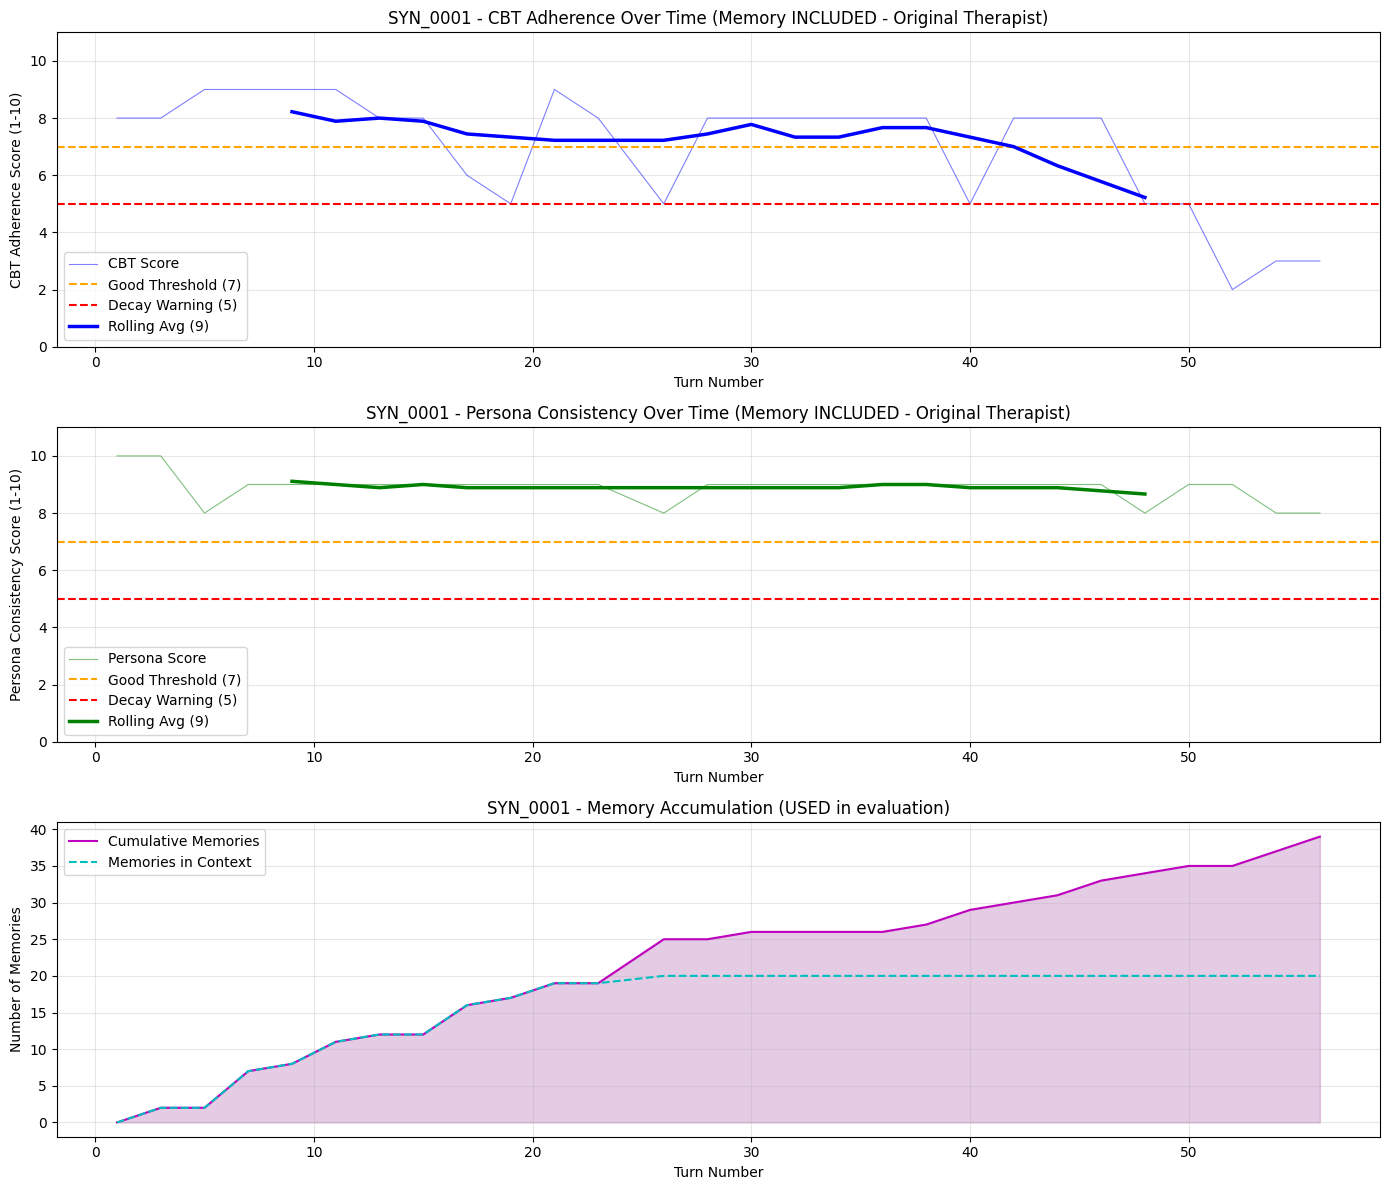

Figure saved to output_therapy_memincluded_SYN_0001\images\alignment_overview.png

Visualizing 39 evaluations for SYN_0002


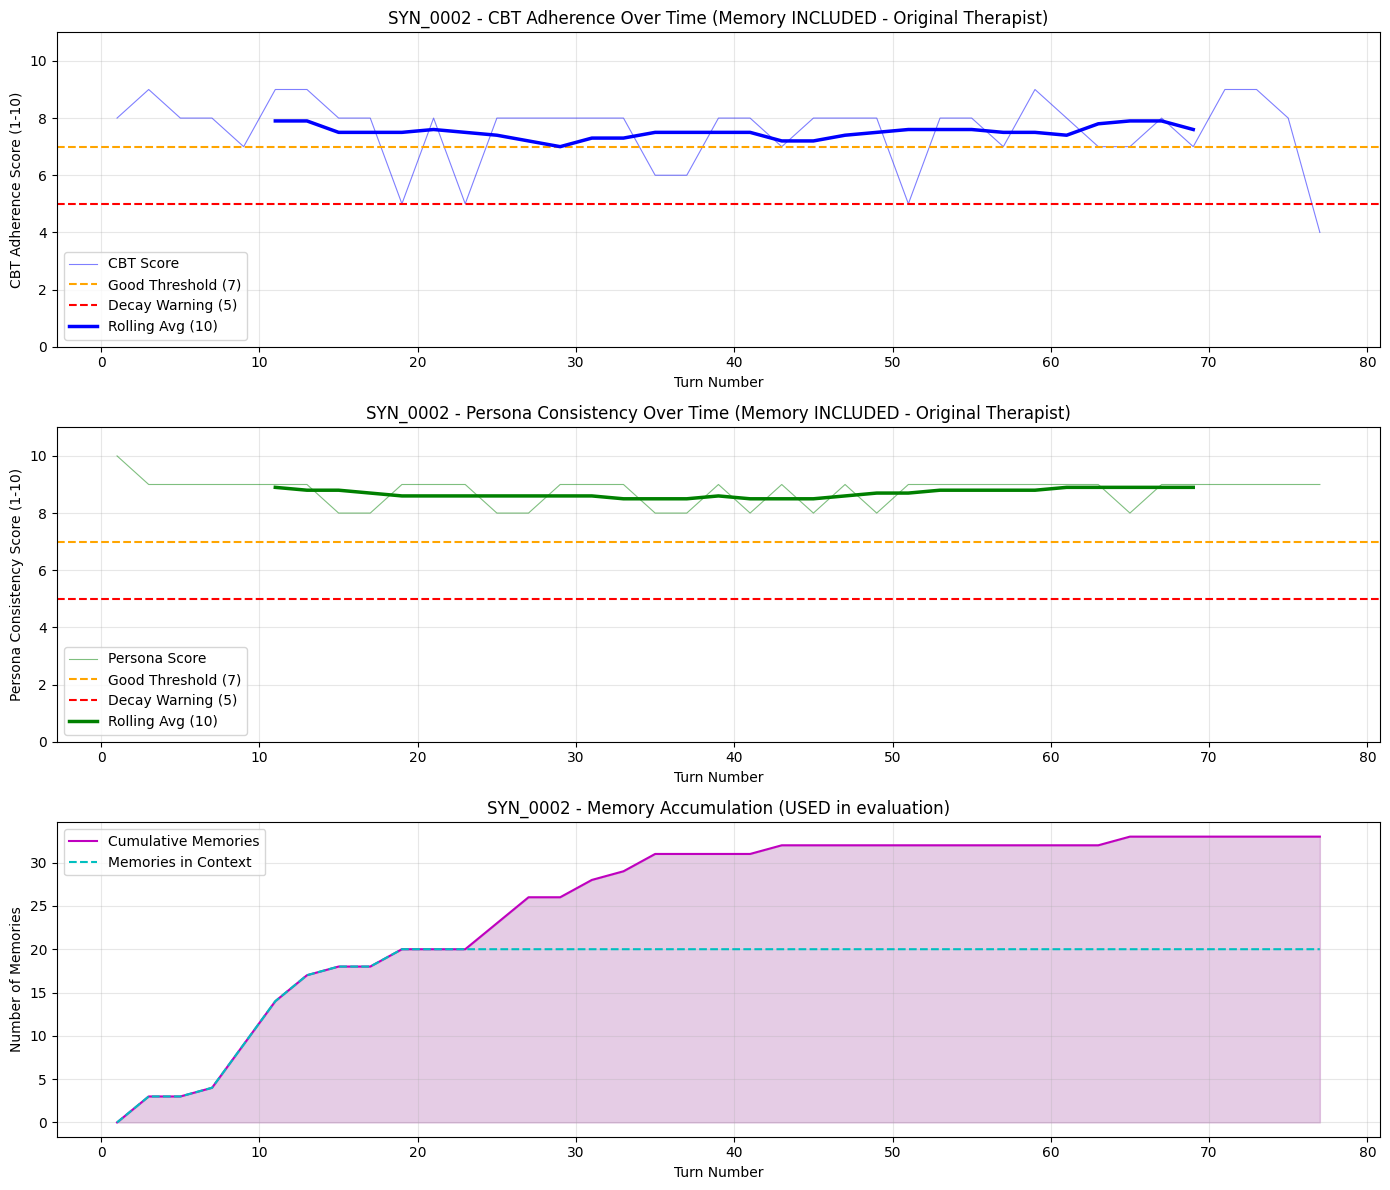

Figure saved to output_therapy_memincluded_SYN_0002\images\alignment_overview.png

Visualizing 25 evaluations for SYN_0004


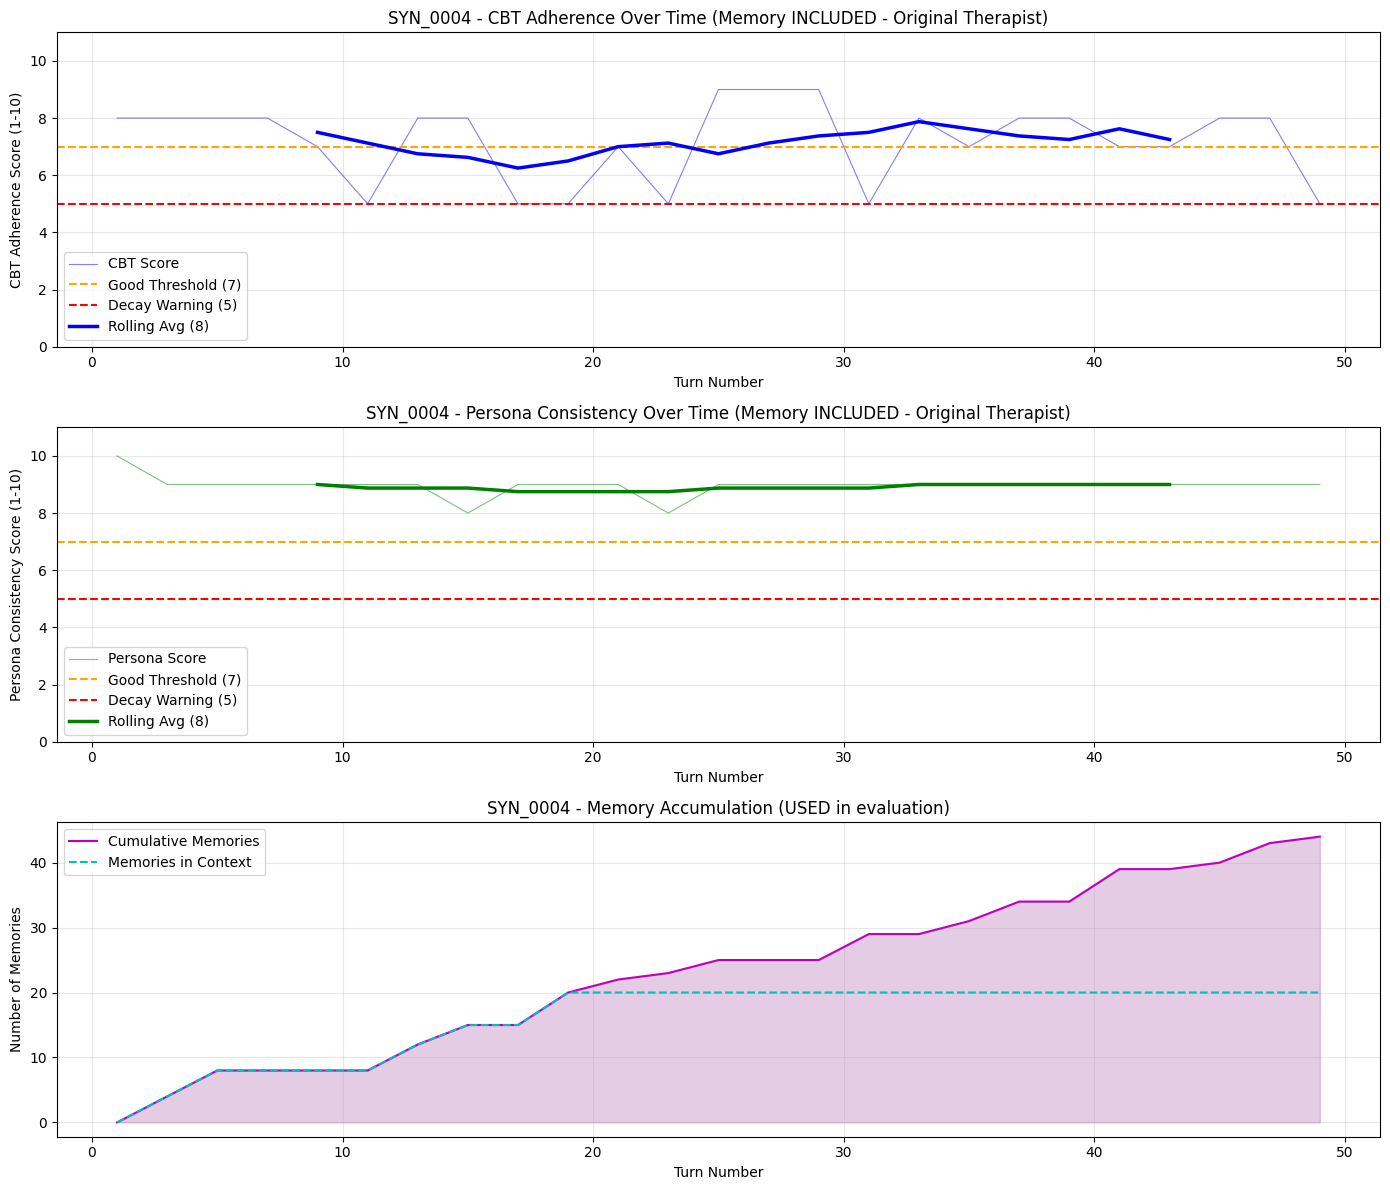

Figure saved to output_therapy_memincluded_SYN_0004\images\alignment_overview.png


In [9]:
# Cell 9: Visualization - Per-patient plots
import matplotlib.pyplot as plt
import numpy as np

for patient in PATIENTS:
    patient_id = patient["id"]
    result_data = all_patient_results[patient_id]
    output_dir = Path(patient["output_dir"])

    cbt_results = result_data["cbt_results"]
    persona_results = result_data["persona_results"]
    memory_snapshots = result_data["memory_snapshots"]

    if not cbt_results:
        print(f"No results for {patient_id}, skipping visualization.")
        continue

    all_cbt_scores = [r["score"] for r in cbt_results]
    all_persona_scores = [r["score"] for r in persona_results]
    all_memory_counts = [s["memory_count"] for s in memory_snapshots]
    all_memories_in_context = [s["memories_in_context"] for s in memory_snapshots]
    eval_turn_numbers = [r["turn_number"] for r in cbt_results]

    print(f"\nVisualizing {len(all_cbt_scores)} evaluations for {patient_id}")

    fig, axes = plt.subplots(3, 1, figsize=(14, 12))

    # Plot 1: CBT Adherence
    ax1 = axes[0]
    ax1.plot(eval_turn_numbers, all_cbt_scores, 'b-', linewidth=0.8, alpha=0.5, label='CBT Score')
    ax1.axhline(y=7, color='orange', linestyle='--', label='Good Threshold (7)')
    ax1.axhline(y=5, color='red', linestyle='--', label='Decay Warning (5)')
    window = min(10, len(all_cbt_scores)//3) if len(all_cbt_scores) > 10 else max(2, len(all_cbt_scores)//2)
    if len(all_cbt_scores) >= window and window > 1:
        rolling_avg = np.convolve(all_cbt_scores, np.ones(window)/window, mode='valid')
        rolling_turns = eval_turn_numbers[window//2:len(rolling_avg) + window//2]
        ax1.plot(rolling_turns, rolling_avg, 'b-', linewidth=2.5, label=f'Rolling Avg ({window})')
    ax1.set_xlabel('Turn Number')
    ax1.set_ylabel('CBT Adherence Score (1-10)')
    ax1.set_title(f'{patient_id} - CBT Adherence Over Time (Memory INCLUDED - Original Therapist)')
    ax1.legend(loc='lower left')
    ax1.set_ylim(0, 11)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Persona Consistency
    ax2 = axes[1]
    ax2.plot(eval_turn_numbers, all_persona_scores, 'g-', linewidth=0.8, alpha=0.5, label='Persona Score')
    ax2.axhline(y=7, color='orange', linestyle='--', label='Good Threshold (7)')
    ax2.axhline(y=5, color='red', linestyle='--', label='Decay Warning (5)')
    if len(all_persona_scores) >= window and window > 1:
        rolling_avg2 = np.convolve(all_persona_scores, np.ones(window)/window, mode='valid')
        rolling_turns2 = eval_turn_numbers[window//2:len(rolling_avg2) + window//2]
        ax2.plot(rolling_turns2, rolling_avg2, 'g-', linewidth=2.5, label=f'Rolling Avg ({window})')
    ax2.set_xlabel('Turn Number')
    ax2.set_ylabel('Persona Consistency Score (1-10)')
    ax2.set_title(f'{patient_id} - Persona Consistency Over Time (Memory INCLUDED - Original Therapist)')
    ax2.legend(loc='lower left')
    ax2.set_ylim(0, 11)
    ax2.grid(True, alpha=0.3)

    # Plot 3: Memory Growth and Context
    ax3 = axes[2]
    memory_turn_numbers = [s["turn_number"] for s in memory_snapshots]
    ax3.plot(memory_turn_numbers, all_memory_counts, 'm-', linewidth=1.5, label='Cumulative Memories')
    ax3.plot(memory_turn_numbers, all_memories_in_context, 'c--', linewidth=1.5, label='Memories in Context')
    ax3.fill_between(memory_turn_numbers, 0, all_memory_counts, alpha=0.2, color='purple')
    ax3.set_xlabel('Turn Number')
    ax3.set_ylabel('Number of Memories')
    ax3.set_title(f'{patient_id} - Memory Accumulation (USED in evaluation)')
    ax3.legend(loc='upper left')
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    image_path = output_dir / "images" / "alignment_overview.png"
    plt.savefig(image_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved to {image_path}")

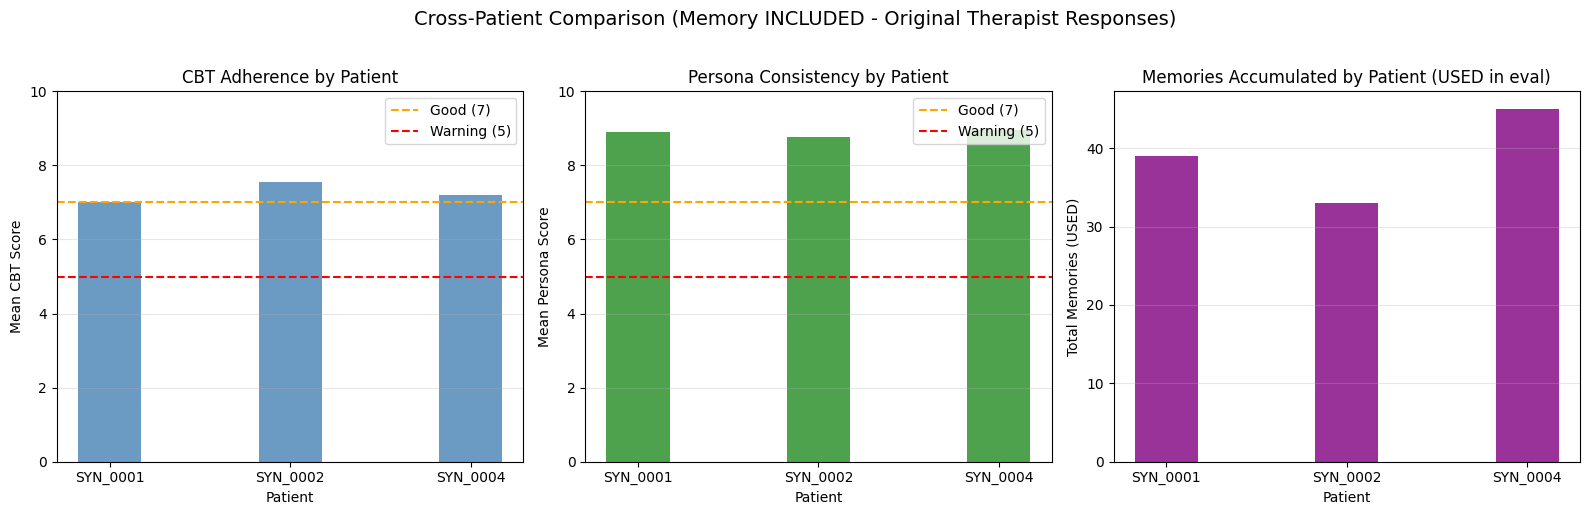


CROSS-PATIENT SUMMARY (Memory INCLUDED - Original Therapist)
Patient      CBT Mean     Persona Mean   Memories  
----------------------------------------------------------------------
SYN_0001     7.00         8.89           39        
SYN_0002     7.56         8.77           33        
SYN_0004     7.20         8.96           45        


In [10]:
# Cell 10: Cross-patient comparison
import matplotlib.pyplot as plt
import numpy as np

patient_ids = [p["id"] for p in PATIENTS]
cbt_means = []
persona_means = []
memory_counts = []

for pid in patient_ids:
    r = all_patient_results[pid]
    cbt_scores = [x["score"] for x in r["cbt_results"]]
    persona_scores = [x["score"] for x in r["persona_results"]]
    cbt_means.append(sum(cbt_scores)/len(cbt_scores) if cbt_scores else 0)
    persona_means.append(sum(persona_scores)/len(persona_scores) if persona_scores else 0)
    memory_counts.append(r["final_memory_count"])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

x = np.arange(len(patient_ids))
width = 0.35

# CBT comparison
ax1 = axes[0]
ax1.bar(x, cbt_means, width, color='steelblue', alpha=0.8)
ax1.axhline(y=7, color='orange', linestyle='--', label='Good (7)')
ax1.axhline(y=5, color='red', linestyle='--', label='Warning (5)')
ax1.set_xlabel('Patient')
ax1.set_ylabel('Mean CBT Score')
ax1.set_title('CBT Adherence by Patient')
ax1.set_xticks(x)
ax1.set_xticklabels(patient_ids)
ax1.set_ylim(0, 10)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Persona comparison
ax2 = axes[1]
ax2.bar(x, persona_means, width, color='forestgreen', alpha=0.8)
ax2.axhline(y=7, color='orange', linestyle='--', label='Good (7)')
ax2.axhline(y=5, color='red', linestyle='--', label='Warning (5)')
ax2.set_xlabel('Patient')
ax2.set_ylabel('Mean Persona Score')
ax2.set_title('Persona Consistency by Patient')
ax2.set_xticks(x)
ax2.set_xticklabels(patient_ids)
ax2.set_ylim(0, 10)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Memory count comparison
ax3 = axes[2]
ax3.bar(x, memory_counts, width, color='purple', alpha=0.8)
ax3.set_xlabel('Patient')
ax3.set_ylabel('Total Memories (USED)')
ax3.set_title('Memories Accumulated by Patient (USED in eval)')
ax3.set_xticks(x)
ax3.set_xticklabels(patient_ids)
ax3.grid(True, alpha=0.3, axis='y')

plt.suptitle('Cross-Patient Comparison (Memory INCLUDED - Original Therapist Responses)', fontsize=14, y=1.02)
plt.tight_layout()

# Save to each patient's output dir
for patient in PATIENTS:
    img_path = Path(patient["output_dir"]) / "images" / "cross_patient_comparison.png"
    plt.savefig(img_path, dpi=150, bbox_inches='tight')

plt.show()

# Print summary table
print("\n" + "=" * 70)
print("CROSS-PATIENT SUMMARY (Memory INCLUDED - Original Therapist)")
print("=" * 70)
print(f"{'Patient':<12} {'CBT Mean':<12} {'Persona Mean':<14} {'Memories':<10}")
print("-" * 70)
for i, pid in enumerate(patient_ids):
    print(f"{pid:<12} {cbt_means[i]:<12.2f} {persona_means[i]:<14.2f} {memory_counts[i]:<10}")